In [1]:
%gui qt
%load_ext autoreload
%autoreload 2


In [2]:
import mne
mne.viz.set_browser_backend('qt')
mne.viz.set_3d_backend('pyvistaqt')
mne.set_config('MNE_DATA', '/workspace/shared/mne_data', set_env=True)

Using qt as 2D backend.
Using pyvistaqt 3d backend.


# 02 — EEG-LFP 对齐 · Source Reconstruction · Connectivity

**完整流程：**
```
EEG (预处理后)          LFP (预处理后)
      |                       |
  检测 STIM_OFF           检测 STIM_OFF
      |                       |
      +------- 计算 offset ----+
      |
  对齐后的 STIM_ON 片段
      |
  +---+---+
  |       |
noise_cov  event-locked epochs
  |       |
  +---+---+
      |
  Source Reconstruction (eLORETA)
      |
  SMA / M1 ROI 时间序列
      |
  Connectivity: SMA/M1 → STN-LFP
  (Granger causality + Coherence)
```

## 0. 环境设置

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import sys
from pathlib import Path
from scipy import signal
from scipy.ndimage import gaussian_filter1d

mne.set_log_level('WARNING')
sys.path.append('/workspace/src')

# ── 路径配置 ──────────────────────────────────────────────────
SAVE_DIR      = Path('/workspace/shared/temp')
DATA_ROOT     = Path('/workspace/shared/data/raw')
SUBJECTS_DIR  = Path('/workspace/shared/data/mne_subjects')
RESULTS_DIR   = Path('/workspace/shared/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SUBJECT_NAME  = 'Roessner_Gerhard'
LFP_FILE      = DATA_ROOT / SUBJECT_NAME / 'lfp' / 'brainsense_55Hz_2iter.json'
TRANS_FILE    = '/workspace/shared/sub-001-trans.fif'
STIM_FREQ     = 55   # Hz

print('✓ 路径设置完成')

✓ 路径设置完成


## 1. 加载预处理后的数据

In [4]:
# 加载 EEG（预处理后的连续数据）
raw_eeg = mne.io.read_raw_fif(
    SAVE_DIR / 'sub-001_eeg_clean.fif', preload=True
)

# 加载 LFP
raw_lfp = mne.io.read_raw_fif(
    SAVE_DIR / 'sub-001_lfp_clean.fif', preload=True
)

print(f'EEG: {len(raw_eeg.ch_names)} ch, '
      f'{raw_eeg.times[-1]:.2f}s, '
      f'{raw_eeg.info["sfreq"]:.0f} Hz')
print(f'LFP: {len(raw_lfp.ch_names)} ch, '
      f'{raw_lfp.times[-1]:.2f}s, '
      f'{raw_lfp.info["sfreq"]:.0f} Hz')

/tmp/ipykernel_142058/3258319591.py:2: RuntimeWarning: This filename (/workspace/shared/temp/sub-001_eeg_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_eeg = mne.io.read_raw_fif(


EEG: 280 ch, 113.88s, 250 Hz
LFP: 4 ch, 118.74s, 250 Hz


/tmp/ipykernel_142058/3258319591.py:7: RuntimeWarning: This filename (/workspace/shared/temp/sub-001_lfp_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_lfp = mne.io.read_raw_fif(


## 2. EEG-LFP 时间对齐

**方法：** 两个信号都含有同一组 STIM_OFF 事件，
通过比对各自时间轴上的 STIM_OFF 起始时刻，计算两路信号的时钟偏移。

In [5]:
# ── 2a. 从 LFP 检测 STIM_OFF 段 ──────────────────────────────
import sys
import numpy as np
sys.path.append('/workspace/src')
from preprocessing import lfp_io

df_ts_sense, df_ts_stim, df_settings = lfp_io.load_lfp_data(LFP_FILE)

# LFP 时间轴（秒）
lfp_sfreq   = float(df_settings['left_sr'].iloc[0])
lfp_n_times = len(df_ts_sense)
lfp_times   = np.arange(lfp_n_times) / lfp_sfreq

# ✅ 用真实 datetime index 对齐，而不是 linspace 均匀分配
# df_ts_stim.index 和 df_ts_sense.index 都是 datetime
off_mask_series = (
    (df_ts_stim['stim_amp_left']  == 0) &
    (df_ts_stim['stim_amp_right'] == 0)
)
off_mask_full = (
    off_mask_series
    .reindex(df_ts_sense.index, method='ffill')  # 前向填充
    .fillna(False)                                # 开头没有 stim 记录时默认 False
    .values
)

# 从 boolean mask 提取连续 OFF 片段
def find_segments(mask, times, min_dur=0.5, max_dur=15.0):
    """从 boolean mask 提取连续片段"""
    transitions = np.diff(np.concatenate([[False], mask, [False]]).astype(int))
    starts = np.where(transitions == 1)[0]
    ends   = np.where(transitions == -1)[0]
    segs = []
    for s, e in zip(starts, ends):
        dur = times[e - 1] - times[s]
        if min_dur <= dur <= max_dur:
            segs.append({'start': times[s], 'end': times[e - 1], 'dur': dur})
    return segs

lfp_off_segs = find_segments(off_mask_full, lfp_times)

print('LFP STIM_OFF 段:')
for i, seg in enumerate(lfp_off_segs):
    print(f'  OFF {i+1}: {seg["start"]:.4f}s → {seg["end"]:.4f}s  (dur={seg["dur"]:.4f}s)')

# 两段 OFF 时长应一致（理论上完全相同，误差只来自 stim 时间戳分辨率）
if len(lfp_off_segs) == 2:
    dur_diff = abs(lfp_off_segs[0]['dur'] - lfp_off_segs[1]['dur'])
    print(f'\n两段 OFF 时长差: {dur_diff*1000:.1f} ms')
    print(f'LFP 采样精度:    {1000/lfp_sfreq:.1f} ms (1 样本)')
    print(f'Stim 时间戳精度: ~{1000*lfp_n_times/len(df_ts_stim)/lfp_sfreq:.0f} ms (1 stim 行)')

LFP STIM_OFF 段:
  OFF 1: 4.7480s → 6.7440s  (dur=1.9960s)
  OFF 2: 103.2480s → 105.2440s  (dur=1.9960s)

两段 OFF 时长差: 0.0 ms
LFP 采样精度:    4.0 ms (1 样本)
Stim 时间戳精度: ~503 ms (1 stim 行)


In [6]:
# ── 2b. 从 EEG 检测 STIM_OFF 段 ──────────────────────────────
# 方法：提取 55 Hz Hilbert 包络，找突变点

def extract_stim_envelope(raw, stim_freq=55, bw=3, smooth_sigma=100):
    """提取刺激频率功率包络（Hilbert 法）"""
    eeg_picks = mne.pick_types(raw.info, eeg=True)
    data  = raw.get_data(picks=eeg_picks[:64])  # 用前 64 通道足够
    sfreq = raw.info['sfreq']
    times = raw.times

    # 带通滤波 → Hilbert → 包络 → 均值
    filt = mne.filter.filter_data(
        data, sfreq=sfreq,
        l_freq=stim_freq - bw, h_freq=stim_freq + bw,
        verbose=False
    )
    envelope  = np.abs(signal.hilbert(filt, axis=1))
    power     = np.mean(envelope, axis=0)
    power_sm  = gaussian_filter1d(power, sigma=smooth_sigma)
    return power, power_sm, times


def detect_off_by_derivative(power_sm, times, min_dur=0.5, max_dur=15.0,
                              deriv_thresh_std=2.5):
    """用一阶导数（突变）检测 STIM_OFF"""
    dt      = np.diff(power_sm)
    dt_std  = np.std(dt)

    drop_thr =  -dt_std * deriv_thresh_std   # 负导数 = 突然下降
    rise_thr =   dt_std * deriv_thresh_std   # 正导数 = 突然上升

    drop_pts = np.where(dt < drop_thr)[0]
    rise_pts = np.where(dt > rise_thr)[0]

    # 对簇取代表点（最大梯度）
    def cluster_peaks(pts, gap=50):
        if len(pts) == 0:
            return []
        clusters, cur = [[pts[0]]], [pts[0]]
        for p in pts[1:]:
            if p - cur[-1] < gap:
                cur.append(p)
            else:
                clusters.append(cur)
                cur = [p]
        return [c[np.argmin(dt[c])] if dt[c[0]] < 0 else c[np.argmax(dt[c])]
                for c in clusters]

    drops = sorted(cluster_peaks(drop_pts))
    rises = sorted([c[np.argmax(dt[c])]
                    for c in [list(g) for g in
                    [rise_pts[np.where(np.diff(np.concatenate([[-999], rise_pts])) > 50)[0]]
                    ]]
                    if len(c)])

    # 重新用简单方法配对
    from scipy.signal import find_peaks
    neg_dt   = -dt
    pos_dt   = dt.copy()
    drop_idx, _ = find_peaks(neg_dt, height=dt_std * deriv_thresh_std, distance=int(0.5 * raw_eeg.info['sfreq']))
    rise_idx, _ = find_peaks(pos_dt, height=dt_std * deriv_thresh_std, distance=int(0.5 * raw_eeg.info['sfreq']))

    # 配对：每个 drop 后面最近的 rise
    segs = []
    for d in drop_idx:
        r_after = rise_idx[rise_idx > d]
        if len(r_after) == 0:
            continue
        r = r_after[0]
        dur = times[r] - times[d]
        if min_dur <= dur <= max_dur:
            segs.append({'start': times[d], 'end': times[r], 'dur': dur,
                         'drop_idx': d, 'rise_idx': r})
    return segs, dt, drop_idx, rise_idx


eeg_power_raw, eeg_power_sm, eeg_times = extract_stim_envelope(raw_eeg, STIM_FREQ)
eeg_off_segs, eeg_dt, eeg_drops, eeg_rises = detect_off_by_derivative(
    eeg_power_sm, eeg_times
)

print('EEG STIM_OFF 段:')
for i, seg in enumerate(eeg_off_segs):
    print(f'  OFF {i+1}: {seg["start"]:.3f}s → {seg["end"]:.3f}s  (dur={seg["dur"]:.3f}s)')

EEG STIM_OFF 段:
  OFF 1: 7.684s → 9.688s  (dur=2.004s)
  OFF 2: 105.916s → 107.864s  (dur=1.948s)


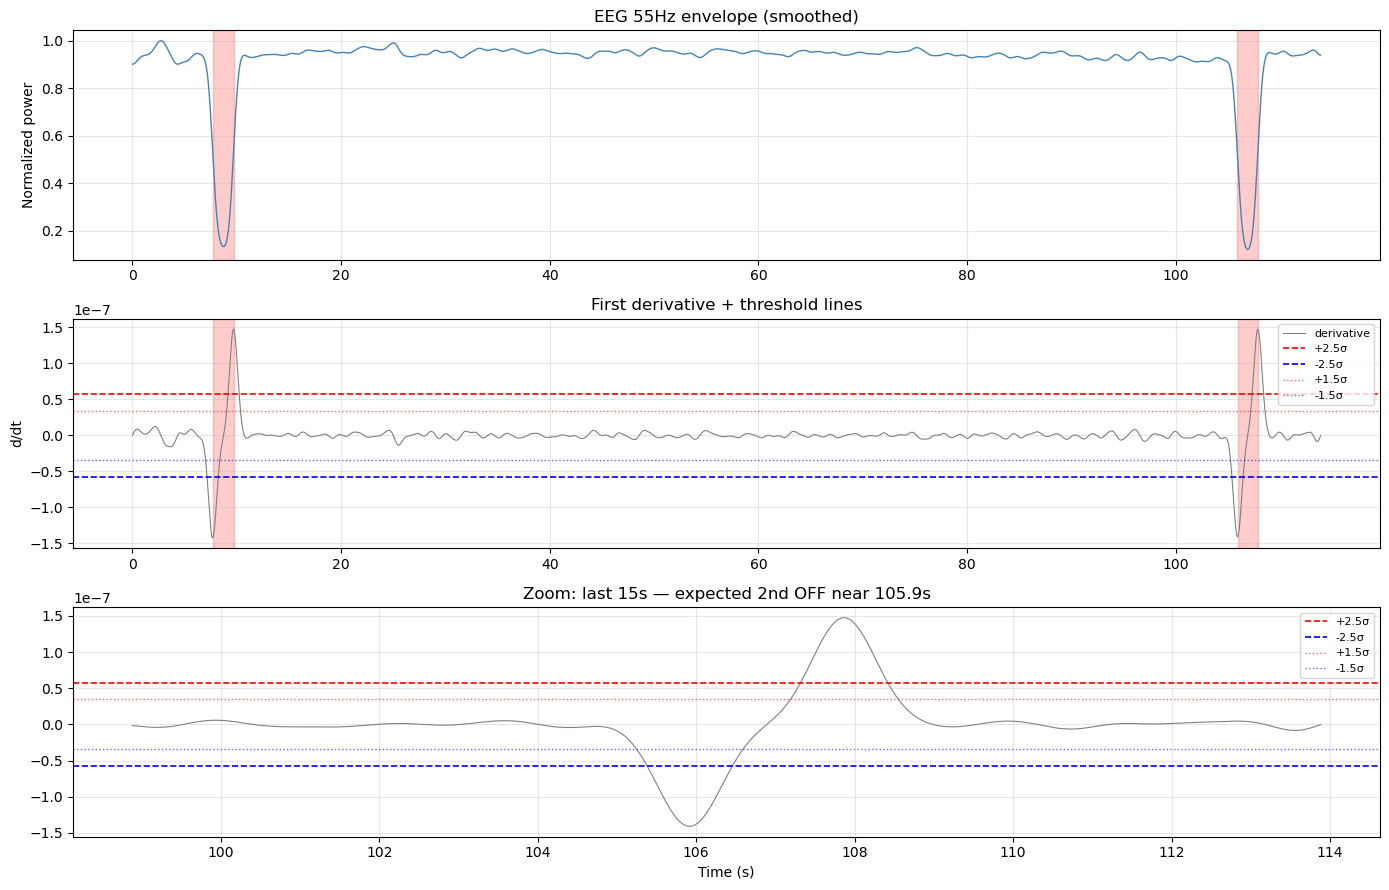

EEG sfreq:       250 Hz
Signal length:   113.88s  (28472 samples)
dt array length: 28471

|dt| max in OFF1 window  (6–11s):    0.000000
|dt| max in OFF2 window  (103–110s): 0.000000
Current threshold (2.5σ):            0.000000
Lower  threshold  (1.5σ):            0.000000


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

dt     = np.diff(eeg_power_sm)
dt_std = np.std(dt)
t_dt   = eeg_times[:-1]   # derivative time axis (one point shorter)

# Plot 1: full envelope
axes[0].plot(eeg_times, eeg_power_sm / eeg_power_sm.max(), 'steelblue', lw=1)
axes[0].set_title('EEG 55Hz envelope (smoothed)')
axes[0].set_ylabel('Normalized power')

# Plot 2: derivative + thresholds
axes[1].plot(t_dt, dt, 'gray', lw=0.8, label='derivative')
axes[1].axhline( dt_std * 2.5, color='red',  ls='--', lw=1.2, label='+2.5σ')
axes[1].axhline(-dt_std * 2.5, color='blue', ls='--', lw=1.2, label='-2.5σ')
axes[1].axhline( dt_std * 1.5, color='red',  ls=':',  lw=1.0, alpha=0.6, label='+1.5σ')
axes[1].axhline(-dt_std * 1.5, color='blue', ls=':',  lw=1.0, alpha=0.6, label='-1.5σ')
axes[1].set_title('First derivative + threshold lines')
axes[1].set_ylabel('d/dt')
axes[1].legend(fontsize=8)

# Mark detected segment
for seg in eeg_off_segs:
    for ax in axes[:2]:
        ax.axvspan(seg['start'], seg['end'], color='red', alpha=0.2, label='detected OFF')

# Plot 3: zoom into tail (last 15s)
t_zoom_start = max(0, eeg_times[-1] - 15)
mask_zoom    = t_dt >= t_zoom_start
axes[2].plot(t_dt[mask_zoom], dt[mask_zoom], 'gray', lw=0.8)
axes[2].axhline( dt_std * 2.5, color='red',  ls='--', lw=1.2, label='+2.5σ')
axes[2].axhline(-dt_std * 2.5, color='blue', ls='--', lw=1.2, label='-2.5σ')
axes[2].axhline( dt_std * 1.5, color='red',  ls=':',  lw=1.0, alpha=0.6, label='+1.5σ')
axes[2].axhline(-dt_std * 1.5, color='blue', ls=':',  lw=1.0, alpha=0.6, label='-1.5σ')
axes[2].set_title(f'Zoom: last 15s — expected 2nd OFF near {eeg_times[-1]-8:.1f}s')
axes[2].set_xlabel('Time (s)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print derivative magnitude in the two OFF windows using time-based indexing
def dt_max_in_window(t_arr, dt_arr, t_start, t_end):
    mask = (t_arr >= t_start) & (t_arr <= t_end)
    if mask.sum() == 0:
        return float('nan')
    return np.max(np.abs(dt_arr[mask]))

print(f'EEG sfreq:       {raw_eeg.info["sfreq"]:.0f} Hz')
print(f'Signal length:   {eeg_times[-1]:.2f}s  ({len(eeg_times)} samples)')
print(f'dt array length: {len(dt)}')
print()
print(f'|dt| max in OFF1 window  (6–11s):    {dt_max_in_window(t_dt, dt, 6, 11):.6f}')
print(f'|dt| max in OFF2 window  (103–110s): {dt_max_in_window(t_dt, dt, 103, 110):.6f}')
print(f'Current threshold (2.5σ):            {dt_std * 2.5:.6f}')
print(f'Lower  threshold  (1.5σ):            {dt_std * 1.5:.6f}')

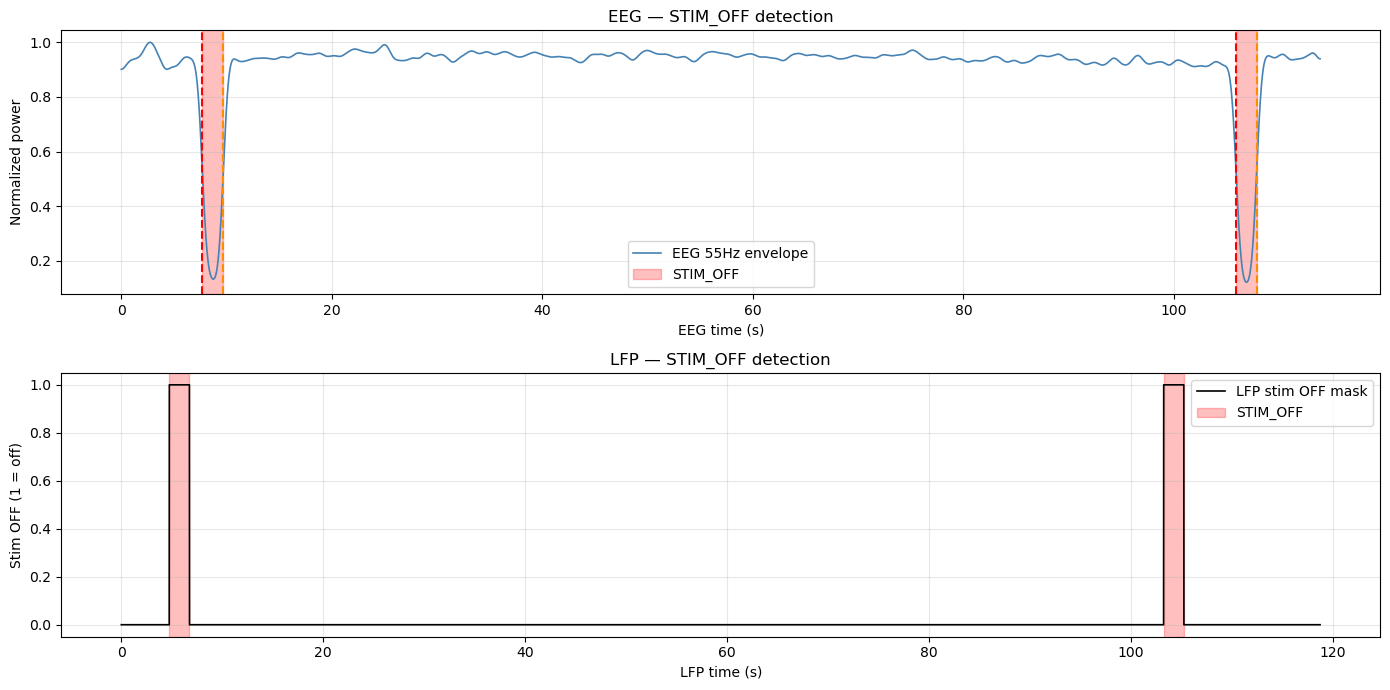

In [8]:
# ── 2c. 可视化对比两路信号的 STIM_OFF 检测结果 ──────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# EEG
ax = axes[0]
ax.plot(eeg_times, eeg_power_sm / eeg_power_sm.max(),
        'steelblue', lw=1.2, label='EEG 55Hz envelope')
for i, seg in enumerate(eeg_off_segs):
    ax.axvspan(seg['start'], seg['end'], color='red', alpha=0.25,
               label='STIM_OFF' if i == 0 else '')
    ax.axvline(seg['start'], color='red',    lw=1.5, ls='--')
    ax.axvline(seg['end'],   color='darkorange', lw=1.5, ls='--')
ax.set_ylabel('Normalized power')
ax.set_xlabel('EEG time (s)')
ax.set_title('EEG — STIM_OFF detection')
ax.legend(); ax.grid(alpha=0.3)

# LFP
ax2 = axes[1]
ax2.plot(lfp_times, off_mask_full.astype(float),
         'k', lw=1.2, label='LFP stim OFF mask')
for i, seg in enumerate(lfp_off_segs):
    ax2.axvspan(seg['start'], seg['end'], color='red', alpha=0.25,
                label='STIM_OFF' if i == 0 else '')
ax2.set_ylabel('Stim OFF (1 = off)')
ax2.set_xlabel('LFP time (s)')
ax2.set_title('LFP — STIM_OFF detection')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'stim_off_detection.png', dpi=150)
plt.show()

In [9]:
## 2d — 用中点估算 offset（更稳健）
eeg_off1_mid = (eeg_off_segs[0]['start'] + eeg_off_segs[0]['end']) / 2
eeg_off2_mid = (eeg_off_segs[1]['start'] + eeg_off_segs[1]['end']) / 2
lfp_off1_mid = (lfp_off_segs[0]['start'] + lfp_off_segs[0]['end']) / 2
lfp_off2_mid = (lfp_off_segs[1]['start'] + lfp_off_segs[1]['end']) / 2

offset_1 = lfp_off1_mid - eeg_off1_mid
offset_2 = lfp_off2_mid - eeg_off2_mid
time_offset = (offset_1 + offset_2) / 2

eeg_gap = eeg_off2_mid - eeg_off1_mid
lfp_gap = lfp_off2_mid - lfp_off1_mid

print('=' * 50)
print(f'EEG  OFF1 mid: {eeg_off1_mid:.4f}s')
print(f'EEG  OFF2 mid: {eeg_off2_mid:.4f}s')
print(f'LFP  OFF1 mid: {lfp_off1_mid:.4f}s')
print(f'LFP  OFF2 mid: {lfp_off2_mid:.4f}s')
print('-' * 50)
print(f'Offset estimate 1:  {offset_1:.4f}s')
print(f'Offset estimate 2:  {offset_2:.4f}s')
print(f'Offset difference:  {abs(offset_1 - offset_2)*1000:.1f}ms  <- should be < 200ms')
print(f'EEG inter-OFF gap:  {eeg_gap:.3f}s')
print(f'LFP inter-OFF gap:  {lfp_gap:.3f}s')
print(f'Gap difference:     {abs(eeg_gap - lfp_gap)*1000:.1f}ms')
print('=' * 50)
print(f'Final time_offset = {time_offset:.4f}s')
print(f'Meaning: LFP_time = EEG_time + ({time_offset:.4f}s)')

EEG  OFF1 mid: 8.6860s
EEG  OFF2 mid: 106.8900s
LFP  OFF1 mid: 5.7460s
LFP  OFF2 mid: 104.2460s
--------------------------------------------------
Offset estimate 1:  -2.9400s
Offset estimate 2:  -2.6440s
Offset difference:  296.0ms  <- should be < 200ms
EEG inter-OFF gap:  98.204s
LFP inter-OFF gap:  98.500s
Gap difference:     296.0ms
Final time_offset = -2.7920s
Meaning: LFP_time = EEG_time + (-2.7920s)


In [10]:
# ── 2e. 截取对齐后的 STIM_ON 片段 ────────────────────────────
# STIM_ON 片段 = 两段 OFF 中间

# LFP 时间轴为基准
lfp_on_start  = lfp_off_segs[0]['end']
lfp_on_end    = lfp_off_segs[1]['start']

# 转换到 EEG 时间轴
eeg_on_start  = lfp_on_start - time_offset
eeg_on_end    = lfp_on_end   - time_offset

# 保留 1s 边缘裕量（去掉刺激切换的瞬态）
MARGIN = 1.0
raw_eeg_on = raw_eeg.copy().crop(eeg_on_start + MARGIN, eeg_on_end - MARGIN)
raw_lfp_on = raw_lfp.copy().crop(lfp_on_start + MARGIN, lfp_on_end - MARGIN)

print(f'STIM_ON 片段 (LFP 轴): {lfp_on_start:.2f}s → {lfp_on_end:.2f}s  ({lfp_on_end-lfp_on_start:.1f}s)')
print(f'STIM_ON 片段 (EEG 轴): {eeg_on_start:.2f}s → {eeg_on_end:.2f}s  ({eeg_on_end-eeg_on_start:.1f}s)')
print(f'裁剪后 EEG: {raw_eeg_on.times[-1]:.2f}s')
print(f'裁剪后 LFP: {raw_lfp_on.times[-1]:.2f}s')

STIM_ON 片段 (LFP 轴): 6.74s → 103.25s  (96.5s)
STIM_ON 片段 (EEG 轴): 9.54s → 106.04s  (96.5s)
裁剪后 EEG: 94.50s
裁剪后 LFP: 94.50s


## 3. Noise Covariance（从 STIM_OFF 计算）

/tmp/ipykernel_142058/1903431545.py:12: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_off = mne.concatenate_epochs(off_epochs_list)


STIM_OFF epochs: 7 x 0.5s


/tmp/ipykernel_142058/1903431545.py:16: RuntimeWarning: Too few samples (required : 1405 got : 875), covariance estimate may be unreliable
  noise_cov = mne.compute_covariance(


✓ Noise covariance 计算完成


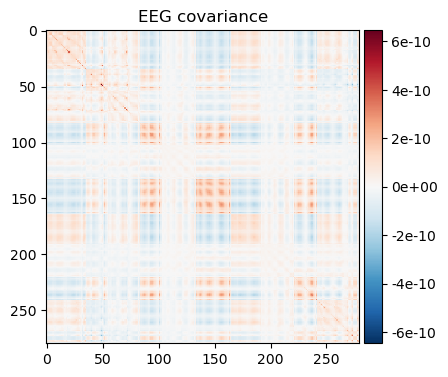

(<Figure size 380x370 with 2 Axes>, None)

In [11]:
# 截取两段 STIM_OFF EEG（用 EEG 时间轴）
EPOCH_LEN = 0.5   # 缩短到 0.5s，每段 OFF (~2s) 能切出约 4 个 epoch

off_epochs_list = []
for seg in eeg_off_segs[:2]:
    raw_off = raw_eeg.copy().crop(seg['start'], seg['end'])
    ep = mne.make_fixed_length_epochs(
        raw_off, duration=EPOCH_LEN, overlap=0.0, preload=True
    )
    off_epochs_list.append(ep)

epochs_off = mne.concatenate_epochs(off_epochs_list)
print(f'STIM_OFF epochs: {len(epochs_off)} x {EPOCH_LEN}s')
# 期望: ~8 个 epochs x 0.5s x 250Hz = 1000 samples

noise_cov = mne.compute_covariance(
    epochs_off,
    method='shrunk',
    rank='info',
    verbose=False
)
print('✓ Noise covariance 计算完成')
mne.viz.plot_cov(noise_cov, epochs_off.info, show_svd=False)

## 4. Forward Solution & Inverse Operator

In [12]:
from pathlib import Path

subject     = 'fsaverage'
fs_dir      = SUBJECTS_DIR / subject
src_path    = fs_dir / 'bem' / 'fsaverage-ico-5-src.fif'
bem_path    = fs_dir / 'bem' / 'fsaverage-5120-5120-5120-bem-sol.fif'

# 验证文件存在
for p in [src_path, bem_path, Path(TRANS_FILE)]:
    assert p.exists(), f'文件不存在: {p}'
print('✓ 所有必要文件存在')

# 计算 Forward Solution
fwd = mne.make_forward_solution(
    info=raw_eeg_on.info,
    trans=TRANS_FILE,
    src=str(src_path),
    bem=str(bem_path),
    eeg=True, meg=False,
    mindist=5.0,
    verbose=False
)
print(f'✓ Forward solution: {fwd["nsource"]} sources, {fwd["nchan"]} channels')

✓ 所有必要文件存在
✓ Forward solution: 20484 sources, 280 channels


In [13]:
from mne.minimum_norm import make_inverse_operator

# 用 STIM_ON 片段的 epochs 构建 inverse operator
epochs_on = mne.make_fixed_length_epochs(
    raw_eeg_on, duration=2.0, overlap=0.0, preload=True
)
print(f'STIM_ON epochs: {len(epochs_on)} × 2.0s')

inverse_operator = make_inverse_operator(
    info=epochs_on.info,
    forward=fwd,
    noise_cov=noise_cov,
    loose=0.2,
    depth=0.8,
    verbose=False
)
print('✓ Inverse operator 构建完成')

STIM_ON epochs: 47 × 2.0s
✓ Inverse operator 构建完成


In [17]:
from mne.minimum_norm import apply_inverse, make_inverse_operator

# ── Rebuild with ico-4 source space ──────────────────────────
src_ico4_path = fs_dir / 'bem' / 'fsaverage-ico-4-src.fif'

if not src_ico4_path.exists():
    print('Creating ico-4 source space...')
    src_ico4 = mne.setup_source_space(
        'fsaverage', spacing='ico4',
        subjects_dir=str(SUBJECTS_DIR), verbose=False
    )
    mne.write_source_spaces(str(src_ico4_path), src_ico4)
    print('✓ Saved ico-4 source space')
else:
    src_ico4 = mne.read_source_spaces(str(src_ico4_path), verbose=False)
    print('✓ Loaded ico-4 source space')

# Rebuild forward solution
fwd_ico4 = mne.make_forward_solution(
    info=raw_eeg_on.info,
    trans=TRANS_FILE,
    src=src_ico4,
    bem=str(bem_path),
    eeg=True, meg=False,
    mindist=5.0, verbose=False
)
print(f'✓ Forward: {fwd_ico4["nsource"]} sources (was {fwd["nsource"]} with ico-5)')

# Rebuild inverse operator
inverse_operator_ico4 = make_inverse_operator(
    info=epochs_on.info,
    forward=fwd_ico4,
    noise_cov=noise_cov,
    loose=0.2, depth=0.8,
    verbose=False
)
print('✓ Inverse operator ready')

# Test with evoked first
lambda2 = 1.0 / 9.0
method  = 'eLORETA'

stc_mean = apply_inverse(
    epochs_on.average(),
    inverse_operator_ico4,
    lambda2=lambda2,
    method=method,
    pick_ori='normal',
    verbose=False
)
print(f'✓ Mean STC shape: {stc_mean.data.shape}')
# Expected: (~5120 sources, n_times)

Creating ico-4 source space...
✓ Saved ico-4 source space
✓ Forward: 5124 sources (was 20484 with ico-5)
✓ Inverse operator ready
✓ Mean STC shape: (5124, 500)


## 5. Source Reconstruction (eLORETA, per-epoch)

In [18]:
import pickle

# Save all objects needed for Section 6 onwards
checkpoint = {
    'fwd_ico4':             fwd_ico4,
    'inverse_operator_ico4': inverse_operator_ico4,
    'stc_mean':             stc_mean,
    'noise_cov':            noise_cov,
    'time_offset':          time_offset,
    'eeg_off_segs':         eeg_off_segs,
    'lfp_off_segs':         lfp_off_segs,
    'eeg_on_start':         eeg_on_start,
    'eeg_on_end':           eeg_on_end,
}

ckpt_path = RESULTS_DIR / 'checkpoint_before_per_epoch.pkl'
with open(ckpt_path, 'wb') as f:
    pickle.dump(checkpoint, f)

# MNE objects need their own save format
mne.minimum_norm.write_inverse_operator(
    str(RESULTS_DIR / 'inverse_operator_ico4-inv.fif'),
    inverse_operator_ico4
)
mne.write_forward_solution(
    str(RESULTS_DIR / 'fwd_ico4-fwd.fif'),
    fwd_ico4, overwrite=True
)
noise_cov.save(str(RESULTS_DIR / 'noise_cov-cov.fif'), overwrite=True)

print('✓ Checkpoint saved')

✓ Checkpoint saved


In [19]:
epochs_on.set_eeg_reference('average', projection=True, verbose=False)

/tmp/ipykernel_142058/3185218914.py:1: RuntimeWarning: An average reference projection was already added. The data has been left untouched.
  epochs_on.set_eeg_reference('average', projection=True, verbose=False)


<Epochs | 47 events (all good), 0 – 1.996 s (baseline off), ~50.6 MiB, data loaded,
 '1': 47>

In [20]:
from mne.minimum_norm import apply_inverse_epochs

stcs = apply_inverse_epochs(
    epochs_on,
    inverse_operator_ico4,
    lambda2=lambda2,
    method=method,
    pick_ori='normal',
    verbose=False
)
print(f'✓ {len(stcs)} STCs, shape: {stcs[0].data.shape}')

✓ 47 STCs, shape: (5124, 500)


In [ ]:
import pickle

# Restore from checkpoint
ckpt_path = RESULTS_DIR / 'checkpoint_before_per_epoch.pkl'
with open(ckpt_path, 'rb') as f:
    ckpt = pickle.load(f)

time_offset  = ckpt['time_offset']
eeg_off_segs = ckpt['eeg_off_segs']
lfp_off_segs = ckpt['lfp_off_segs']
eeg_on_start = ckpt['eeg_on_start']
eeg_on_end   = ckpt['eeg_on_end']
stc_mean     = ckpt['stc_mean']

# Reload MNE objects
inverse_operator_ico4 = mne.minimum_norm.read_inverse_operator(
    str(RESULTS_DIR / 'inverse_operator_ico4-inv.fif')
)
fwd_ico4  = mne.read_forward_solution(str(RESULTS_DIR / 'fwd_ico4-fwd.fif'))
noise_cov = mne.read_cov(str(RESULTS_DIR / 'noise_cov-cov.fif'))

# Reload EEG and rebuild epochs_on
raw_eeg = mne.io.read_raw_fif(
    '/workspace/shared/data/preprocessed/pre_raw_eeg.fif', preload=True
)
raw_eeg.set_eeg_reference('average', projection=True, verbose=False)
raw_eeg_on = raw_eeg.copy().crop(eeg_on_start + 1.0, eeg_on_end - 1.0)
epochs_on  = mne.make_fixed_length_epochs(
    raw_eeg_on, duration=2.0, overlap=0.0, preload=True
)

lambda2 = 1.0 / 9.0
method  = 'eLORETA'

print(f'✓ Restored: {len(epochs_on)} epochs, offset={time_offset:.4f}s')

In [ ]:
# from mne.minimum_norm import apply_inverse_epochs

# # Process in small batches to avoid OOM
# BATCH_SIZE = 5
# stcs = []

# for i in range(0, len(epochs_on), BATCH_SIZE):
#     batch = epochs_on[i : i + BATCH_SIZE]
#     stcs_batch = apply_inverse_epochs(
#         batch,
#         inverse_operator,
#         lambda2=lambda2,
#         method=method,
#         pick_ori='normal',
#         verbose=False
#     )
#     stcs.extend(stcs_batch)
#     print(f'  Batch {i//BATCH_SIZE + 1}: epochs {i}–{min(i+BATCH_SIZE, len(epochs_on))-1} done')

# print(f'✓ Total STCs: {len(stcs)}, shape: {stcs[0].data.shape}')

Running eLORETA on 47 epochs...


## 6. ROI 时间序列提取（SMA / preSMA / M1）

In [21]:
# 读取 Desikan-Killiany parcellation labels
labels = mne.read_labels_from_annot(
    subject, parc='aparc',
    subjects_dir=str(SUBJECTS_DIR),
    verbose=False
)

# 打印所有 label 名，方便确认
label_names = [l.name for l in labels]
print('可用 Labels (前 20 个):')
print([n for n in label_names if 'frontal' in n.lower() or 'precentral' in n.lower()])

可用 Labels (前 20 个):
['caudalmiddlefrontal-lh', 'caudalmiddlefrontal-rh', 'frontalpole-lh', 'frontalpole-rh', 'lateralorbitofrontal-lh', 'lateralorbitofrontal-rh', 'medialorbitofrontal-lh', 'medialorbitofrontal-rh', 'precentral-lh', 'precentral-rh', 'rostralmiddlefrontal-lh', 'rostralmiddlefrontal-rh', 'superiorfrontal-lh', 'superiorfrontal-rh']


In [22]:
# 选择目标 ROI
# SMA ≈ superiorfrontal (内侧前额叶/辅助运动区)
# M1  ≈ precentral (初级运动皮层)
# 两侧都取，重点用左侧（对侧，因为 STN 是左侧）

roi_defs = {
    'SMA_L':   'superiorfrontal-lh',
    'SMA_R':   'superiorfrontal-rh',
    'M1_L':    'precentral-lh',
    'M1_R':    'precentral-rh',
}

label_map = {l.name: l for l in labels}

# 验证 label 存在
for roi_name, label_name in roi_defs.items():
    if label_name in label_map:
        print(f'  ✓ {roi_name}: {label_name} ({len(label_map[label_name].vertices)} vertices)')
    else:
        print(f'  ✗ {roi_name}: {label_name} 未找到！')

  ✓ SMA_L: superiorfrontal-lh (12179 vertices)
  ✓ SMA_R: superiorfrontal-rh (11878 vertices)
  ✓ M1_L: precentral-lh (10740 vertices)
  ✓ M1_R: precentral-rh (10705 vertices)


In [23]:
def extract_roi_timeseries(stcs, label, src, mode='mean_flip'):
    """
    从多个 source estimate 提取 ROI 时间序列。
    
    Parameters
    ----------
    stcs : list of SourceEstimate
    label : mne.Label
    src : SourceSpaces
    mode : str
        'mean_flip' = 平均并翻转符号（消除方向模糊）
        'mean'      = 简单均值
        'pca_flip'  = 第一 PCA 成分
        
    Returns
    -------
    ts : np.ndarray  shape (n_epochs, n_times)
    """
    ts_list = []
    for stc in stcs:
        tc = stc.extract_label_time_course(
            label, src,
            mode=mode,
            allow_empty=True,
            verbose=False
        )
        ts_list.append(tc[0])   # shape (n_times,)
    return np.array(ts_list)   # shape (n_epochs, n_times)


# 加载 source space（计算 forward 时用的那个）
src = mne.read_source_spaces(str(src_path), verbose=False)

roi_ts = {}
for roi_name, label_name in roi_defs.items():
    if label_name not in label_map:
        print(f'⚠ 跳过 {roi_name}')
        continue
    ts = extract_roi_timeseries(stcs, label_map[label_name], src)
    roi_ts[roi_name] = ts
    print(f'✓ {roi_name}: shape={ts.shape}')

stc_times = stcs[0].times  # 时间轴（相对每个 epoch 的 0s）

✓ SMA_L: shape=(47, 500)
✓ SMA_R: shape=(47, 500)
✓ M1_L: shape=(47, 500)
✓ M1_R: shape=(47, 500)


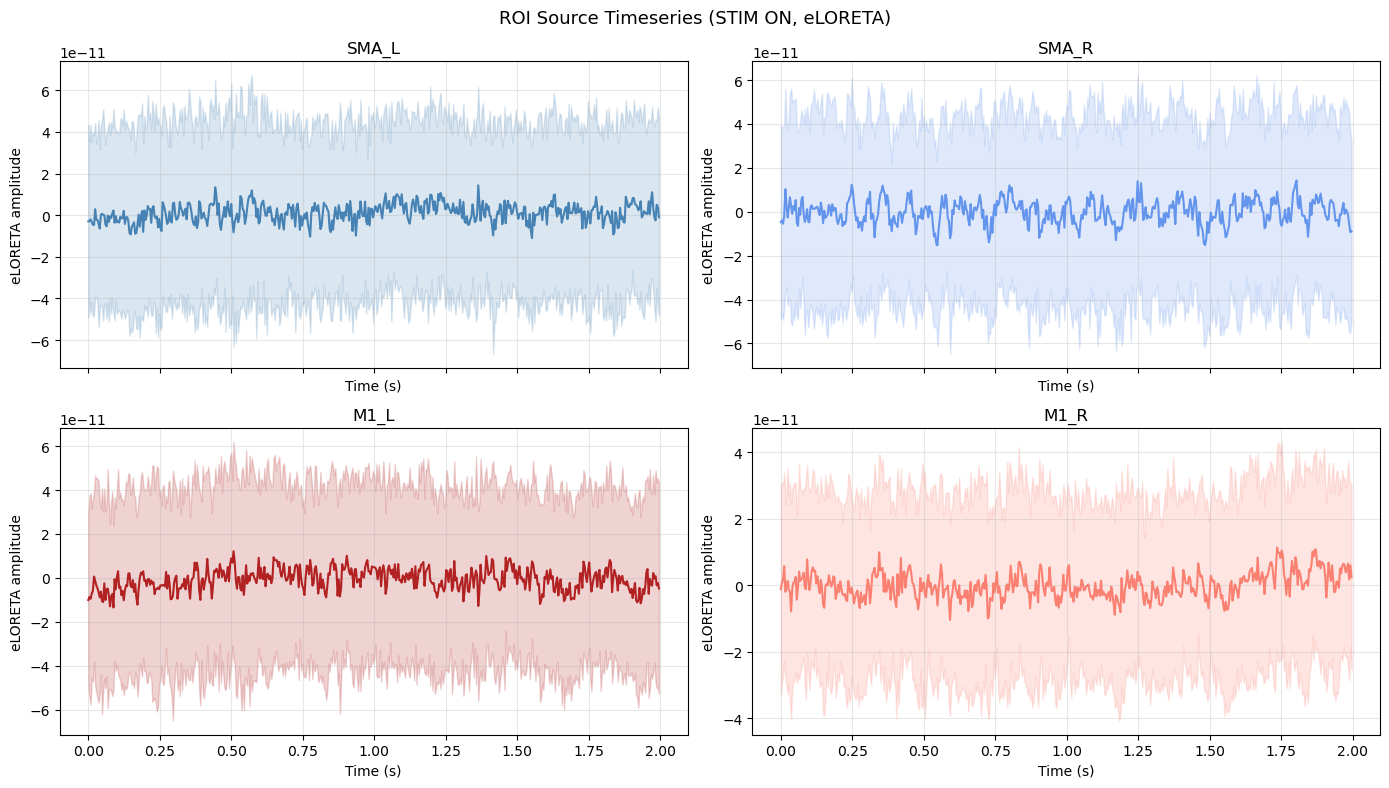

In [24]:
# 可视化各 ROI 的平均时间序列
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
colors = {'SMA_L': 'steelblue', 'SMA_R': 'cornflowerblue',
          'M1_L':  'firebrick',  'M1_R':  'salmon'}

for ax, (roi_name, ts) in zip(axes.flat, roi_ts.items()):
    mean_ts = np.mean(ts, axis=0)
    std_ts  = np.std(ts, axis=0)
    ax.plot(stc_times, mean_ts, color=colors[roi_name], lw=1.5)
    ax.fill_between(stc_times,
                    mean_ts - std_ts, mean_ts + std_ts,
                    color=colors[roi_name], alpha=0.2)
    ax.set_title(roi_name); ax.set_xlabel('Time (s)'); ax.set_ylabel('eLORETA amplitude')
    ax.grid(alpha=0.3)

plt.suptitle('ROI Source Timeseries (STIM ON, eLORETA)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roi_timeseries.png', dpi=150)
plt.show()

## 7. EEG–LFP 对齐并对 LFP 分段

将 LFP STIM_ON 片段切成和 EEG epochs 完全对应的 2s 片段。

In [25]:
# LFP 也切成 2s 固定长度 epochs，与 EEG epochs 对齐
lfp_epochs_on = mne.make_fixed_length_epochs(
    raw_lfp_on, duration=2.0, overlap=0.0, preload=True
)

# 确保 epoch 数一致（取最小值）
n_epochs = min(len(epochs_on), len(lfp_epochs_on))
print(f'EEG epochs: {len(epochs_on)}, LFP epochs: {len(lfp_epochs_on)}')
print(f'→ 使用前 {n_epochs} 个 epochs')

# 提取 LFP 数据 (n_epochs, n_ch, n_times)
lfp_data_epochs = lfp_epochs_on.get_data()[:n_epochs]   # shape: (n_epochs, 2, n_times_lfp)

# 只用左侧 STN（对侧）
lfp_left_idx = lfp_epochs_on.ch_names.index('LFP_L')
lfp_ts = lfp_data_epochs[:, lfp_left_idx, :]  # shape: (n_epochs, n_times_lfp)

# 对齐 ROI 时间序列到同样的 n_epochs
roi_ts_aligned = {k: v[:n_epochs] for k, v in roi_ts.items()}

print(f'LFP timeseries shape:  {lfp_ts.shape}')
print(f'ROI timeseries shape:  {list(roi_ts_aligned.values())[0].shape}')

EEG epochs: 47, LFP epochs: 47
→ 使用前 47 个 epochs
LFP timeseries shape:  (47, 500)
ROI timeseries shape:  (47, 500)


## 8. Connectivity Analysis

**目标：** 验证 SMA/M1 → STN 的 hyperdirect pathway 方向性。

两种互补的方法：
- **Granger Causality (GC):** 在时域检测单向因果，SMA→STN 的 GC 应大于 STN→SMA
- **Coherence / imaginary coherence:** 在频域检测同步性，重点看 beta 频段（13-30 Hz）

In [26]:
# ── 8a. 重采样使 EEG 和 LFP 时间点数一致 ─────────────────────
from scipy.signal import resample

eeg_sfreq = epochs_on.info['sfreq']   # 通常 500 Hz
lfp_sfreq = lfp_epochs_on.info['sfreq']  # 250 Hz

# 统一到 LFP 采样率（更低，减少计算量）
target_sfreq = lfp_sfreq
n_times_lfp  = lfp_ts.shape[1]

# 把 EEG ROI 时间序列降采样到 LFP 采样率
roi_ts_resampled = {}
for roi_name, ts in roi_ts_aligned.items():
    ts_res = resample(ts, n_times_lfp, axis=1)
    roi_ts_resampled[roi_name] = ts_res

print(f'降采样后 ROI shape: {list(roi_ts_resampled.values())[0].shape}')
print(f'LFP shape:          {lfp_ts.shape}')

common_times = np.arange(n_times_lfp) / target_sfreq

降采样后 ROI shape: (47, 500)
LFP shape:          (47, 500)


In [27]:
# ── 8b. Coherence & Imaginary Coherence ──────────────────────
from scipy.signal import csd, welch

def compute_coherence(x_epochs, y_epochs, sfreq, nperseg=256):
    """
    跨 epoch 计算 coherence（平均 cross-spectrum 法）。
    
    返回
    ----
    freqs : np.ndarray
    coh   : np.ndarray  magnitude-squared coherence
    icoh  : np.ndarray  imaginary coherence（不受瞬时耦合伪迹影响）
    """
    Sxx_avg = None
    Syy_avg = None
    Sxy_avg = None

    for x, y in zip(x_epochs, y_epochs):
        freqs, Sxx = welch(x, fs=sfreq, nperseg=nperseg)
        _,     Syy = welch(y, fs=sfreq, nperseg=nperseg)
        _,     Sxy = csd(x, y,  fs=sfreq, nperseg=nperseg)

        Sxx_avg = Sxx if Sxx_avg is None else Sxx_avg + Sxx
        Syy_avg = Syy if Syy_avg is None else Syy_avg + Syy
        Sxy_avg = Sxy if Sxy_avg is None else Sxy_avg + Sxy

    Sxx_avg /= len(x_epochs)
    Syy_avg /= len(x_epochs)
    Sxy_avg /= len(x_epochs)

    coh  = np.abs(Sxy_avg)**2 / (Sxx_avg * Syy_avg + 1e-30)
    icoh = np.imag(Sxy_avg)   / np.sqrt(Sxx_avg * Syy_avg + 1e-30)

    return freqs, coh, icoh


# 计算各 ROI 与 STN-LFP 的 coherence
coh_results = {}
for roi_name, ts in roi_ts_resampled.items():
    freqs, coh, icoh = compute_coherence(ts, lfp_ts, sfreq=target_sfreq)
    coh_results[roi_name] = {'freqs': freqs, 'coh': coh, 'icoh': icoh}
    print(f'✓ Coherence 计算完成: {roi_name}')

print(f'频率分辨率: {freqs[1]-freqs[0]:.2f} Hz, 范围: 0–{freqs[-1]:.0f} Hz')

✓ Coherence 计算完成: SMA_L
✓ Coherence 计算完成: SMA_R
✓ Coherence 计算完成: M1_L
✓ Coherence 计算完成: M1_R
频率分辨率: 0.98 Hz, 范围: 0–125 Hz


In [28]:
# ── 8c. Granger Causality ─────────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

def granger_causality_epochwise(x_epochs, y_epochs, maxlag=10):
    """
    跨 epoch 计算 Granger causality (F 统计量)。
    
    检验：x → y  和  y → x
    返回每个 lag 的 F 值均值。
    """
    f_x_to_y_list = []
    f_y_to_x_list = []

    for x, y in zip(x_epochs, y_epochs):
        # 归一化
        x_n = (x - x.mean()) / (x.std() + 1e-30)
        y_n = (y - y.mean()) / (y.std() + 1e-30)

        try:
            # x → y
            data_xy = np.column_stack([y_n, x_n])
            gc_xy   = grangercausalitytests(data_xy, maxlag=maxlag, verbose=False)
            f_xy    = np.mean([gc_xy[lag][0]['ssr_ftest'][0] for lag in range(1, maxlag+1)])

            # y → x
            data_yx = np.column_stack([x_n, y_n])
            gc_yx   = grangercausalitytests(data_yx, maxlag=maxlag, verbose=False)
            f_yx    = np.mean([gc_yx[lag][0]['ssr_ftest'][0] for lag in range(1, maxlag+1)])

            f_x_to_y_list.append(f_xy)
            f_y_to_x_list.append(f_yx)
        except Exception as e:
            pass  # 跳过问题 epoch

    return {
        'x_to_y': np.mean(f_x_to_y_list),
        'y_to_x': np.mean(f_y_to_x_list),
        'directionality_index': np.mean(f_x_to_y_list) - np.mean(f_y_to_x_list)
    }


print('Computing Granger Causality (ROI → STN-LFP)...')
gc_results = {}
for roi_name, ts in roi_ts_resampled.items():
    gc = granger_causality_epochwise(ts, lfp_ts, maxlag=10)
    gc_results[roi_name] = gc
    print(f'  {roi_name}: '
          f'ROI→STN={gc["x_to_y"]:.2f}, STN→ROI={gc["y_to_x"]:.2f}, '
          f'DI={gc["directionality_index"]:+.2f}')

Computing Granger Causality (ROI → STN-LFP)...
  SMA_L: ROI→STN=45.44, STN→ROI=58.35, DI=-12.91
  SMA_R: ROI→STN=26.81, STN→ROI=31.77, DI=-4.97
  M1_L: ROI→STN=36.34, STN→ROI=57.34, DI=-21.00
  M1_R: ROI→STN=11.91, STN→ROI=25.37, DI=-13.45


## 9. 可视化结果

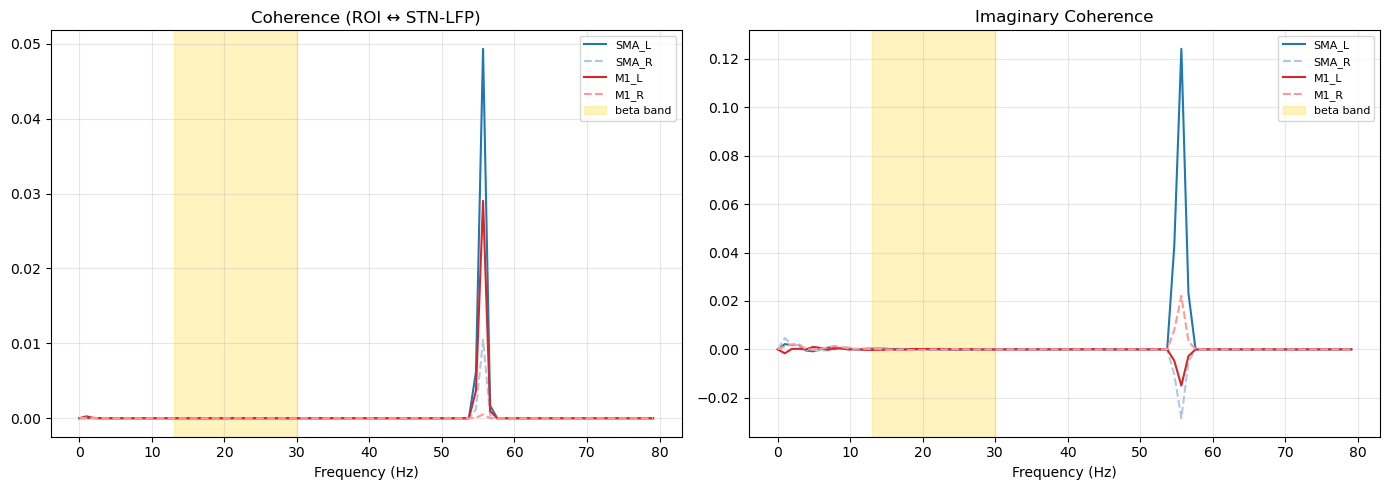

In [29]:
# ── 9a. Coherence 图 ──────────────────────────────────────────
beta_band = (13, 30)
colors_roi = {'SMA_L': '#1f77b4', 'SMA_R': '#aec7e8',
              'M1_L':  '#d62728', 'M1_R':  '#ff9896'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for roi_name, res in coh_results.items():
    freqs, coh, icoh = res['freqs'], res['coh'], res['icoh']
    mask = freqs <= 80  # 只显示 0-80 Hz
    c    = colors_roi[roi_name]
    ls   = '-' if 'L' in roi_name else '--'
    axes[0].plot(freqs[mask], coh[mask],  color=c, ls=ls, lw=1.5, label=roi_name)
    axes[1].plot(freqs[mask], icoh[mask], color=c, ls=ls, lw=1.5, label=roi_name)

for ax, title in zip(axes, ['Coherence (ROI ↔ STN-LFP)',
                              'Imaginary Coherence']):
    ax.axvspan(*beta_band, color='gold', alpha=0.25, label='beta band')
    ax.set_xlabel('Frequency (Hz)'); ax.legend(fontsize=8)
    ax.set_title(title); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'coherence_roi_stn.png', dpi=150)
plt.show()

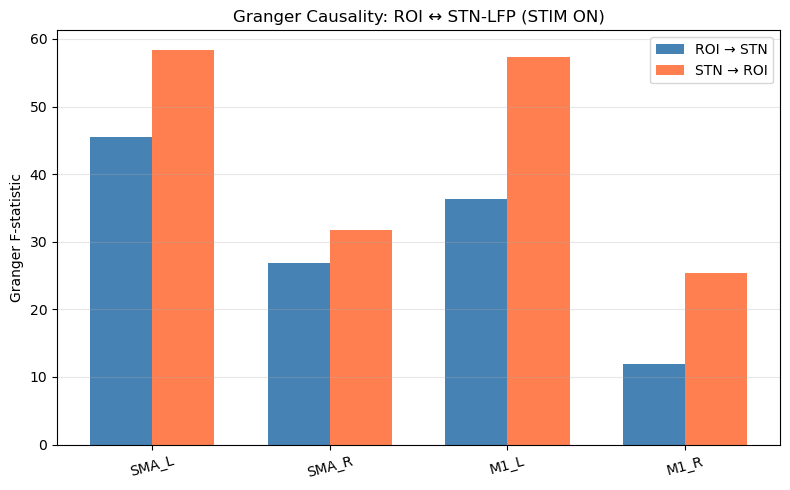


Directionality Index (ROI→STN minus STN→ROI):
(正值 = ROI 更多驱动 STN，符合 hyperdirect pathway 假说)
  ✗ SMA_L: DI = -12.906
  ✗ SMA_R: DI = -4.967
  ✗ M1_L: DI = -21.001
  ✗ M1_R: DI = -13.452


In [30]:
# ── 9b. Granger Causality 汇总图 ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

rois = list(gc_results.keys())
x    = np.arange(len(rois))
width = 0.35

f_roi_to_stn = [gc_results[r]['x_to_y'] for r in rois]
f_stn_to_roi = [gc_results[r]['y_to_x'] for r in rois]

bars1 = ax.bar(x - width/2, f_roi_to_stn, width, label='ROI → STN', color='steelblue')
bars2 = ax.bar(x + width/2, f_stn_to_roi, width, label='STN → ROI', color='coral')

ax.set_xticks(x); ax.set_xticklabels(rois, rotation=15)
ax.set_ylabel('Granger F-statistic')
ax.set_title('Granger Causality: ROI ↔ STN-LFP (STIM ON)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'granger_causality.png', dpi=150)
plt.show()

# Directionality index 汇总
print('\nDirectionality Index (ROI→STN minus STN→ROI):')
print('(正值 = ROI 更多驱动 STN，符合 hyperdirect pathway 假说)')
for roi_name in rois:
    di = gc_results[roi_name]['directionality_index']
    symbol = '✓' if di > 0 else '✗'
    print(f'  {symbol} {roi_name}: DI = {di:+.3f}')

/tmp/ipykernel_142058/2745972783.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rois, rotation=15)


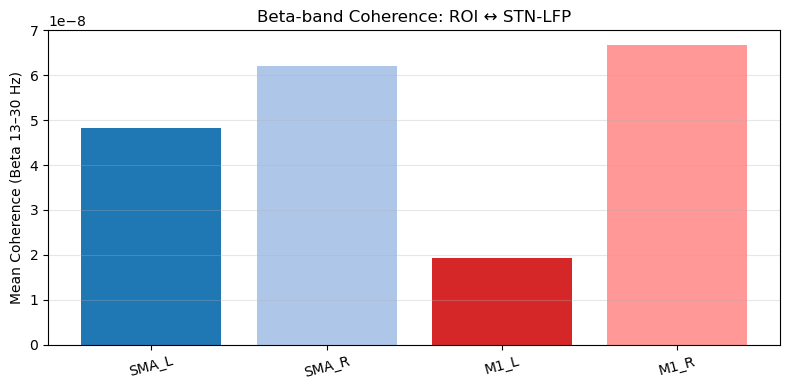

In [31]:
# ── 9c. Beta 频段 coherence 汇总 ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

beta_coh_mean = {}
for roi_name, res in coh_results.items():
    f, coh = res['freqs'], res['coh']
    beta_mask = (f >= beta_band[0]) & (f <= beta_band[1])
    beta_coh_mean[roi_name] = np.mean(coh[beta_mask])

rois  = list(beta_coh_mean.keys())
vals  = list(beta_coh_mean.values())
col   = [colors_roi[r] for r in rois]

ax.bar(rois, vals, color=col)
ax.set_ylabel('Mean Coherence (Beta 13–30 Hz)')
ax.set_title('Beta-band Coherence: ROI ↔ STN-LFP')
ax.set_xticklabels(rois, rotation=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'beta_coherence_summary.png', dpi=150)
plt.show()

## 10. 保存结果

In [32]:
import pickle

# 打包所有结果
results = {
    # 对齐信息
    'time_offset':    time_offset,
    'eeg_off_segs':   eeg_off_segs,
    'lfp_off_segs':   lfp_off_segs,
    'eeg_on_start':   eeg_on_start,
    'eeg_on_end':     eeg_on_end,
    # Source reconstruction
    'roi_ts':         roi_ts_resampled,  # dict: roi_name → (n_epochs, n_times)
    'lfp_ts':         lfp_ts,            # (n_epochs, n_times)
    'stc_times':      stc_times,
    'common_sfreq':   target_sfreq,
    # Connectivity
    'coherence':      coh_results,
    'granger':        gc_results,
}

out_path = RESULTS_DIR / 'sub-001_connectivity_results.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(results, f)

# 也保存为 CSV（方便后续读取）
gc_df = pd.DataFrame(gc_results).T
gc_df.to_csv(RESULTS_DIR / 'granger_causality.csv')

beta_coh_df = pd.DataFrame.from_dict(beta_coh_mean, orient='index', columns=['beta_coherence'])
beta_coh_df.to_csv(RESULTS_DIR / 'beta_coherence.csv')

print(f'✓ 结果已保存:')
print(f'  {out_path}')
print(f'  {RESULTS_DIR}/granger_causality.csv')
print(f'  {RESULTS_DIR}/beta_coherence.csv')
print(f'  {RESULTS_DIR}/coherence_roi_stn.png')
print(f'  {RESULTS_DIR}/granger_causality.png')
print(f'  {RESULTS_DIR}/beta_coherence_summary.png')

✓ 结果已保存:
  /workspace/shared/results/sub-001_connectivity_results.pkl
  /workspace/shared/results/granger_causality.csv
  /workspace/shared/results/beta_coherence.csv
  /workspace/shared/results/coherence_roi_stn.png
  /workspace/shared/results/granger_causality.png
  /workspace/shared/results/beta_coherence_summary.png
